# Machine Learning Forecast

This notebook trains a global gradient-boosting model to predict hourly pickups across all 25 stations.

The model uses:

- Station identity
- Calendar patterns
- Daily and weekly lag values
- Recent rolling demand statistics

In [14]:
from pathlib import Path

import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import (
    mean_absolute_error,
    root_mean_squared_error,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

import matplotlib.pyplot as plt


PROJECT_ROOT = Path.cwd().parent

FEATURE_FILE = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "model_features.parquet"
)

features = pd.read_parquet(FEATURE_FILE)

print(f"Rows: {len(features):,}")
print(f"Columns: {len(features.columns)}")

features.head()

Rows: 63,600
Columns: 18


,timestamp,station_id,station_name,pickups,hour,day_of_week,month,is_weekend,hour_sin,hour_cos,day_of_week_sin,day_of_week_cos,lag_24,lag_48,lag_168,lag_336,rolling_mean_168,rolling_std_168
0,2026-01-15 00:00:00,5340.01,N 7 St & Driggs Ave,2,0,3,1,0,0.000000,1.000000,0.433884,-0.900969,2.0,3.0,4.0,8.0,9.059524,8.552551
1,2026-01-15 01:00:00,5340.01,N 7 St & Driggs Ave,2,1,3,1,0,0.258819,0.965926,0.433884,-0.900969,0.0,0.0,1.0,7.0,9.047619,8.563821
2,2026-01-15 02:00:00,5340.01,N 7 St & Driggs Ave,1,2,3,1,0,0.500000,0.866025,0.433884,-0.900969,0.0,0.0,0.0,14.0,9.041667,8.569794
3,2026-01-15 03:00:00,5340.01,N 7 St & Driggs Ave,0,3,3,1,0,0.707107,0.707107,0.433884,-0.900969,0.0,0.0,0.0,2.0,9.035714,8.575758
4,2026-01-15 04:00:00,5340.01,N 7 St & Driggs Ave,0,4,3,1,0,0.866025,0.500000,0.433884,-0.900969,0.0,0.0,0.0,0.0,9.035714,8.575758


In [2]:
test_start = (
    features["timestamp"].max().normalize()
    - pd.Timedelta(days=6)
)

train = features[
    features["timestamp"] < test_start
].copy()

test = features[
    features["timestamp"] >= test_start
].copy()

print(f"Training starts: {train['timestamp'].min()}")
print(f"Training ends: {train['timestamp'].max()}")
print(f"Testing starts: {test['timestamp'].min()}")
print(f"Testing ends: {test['timestamp'].max()}")
print(f"Training rows: {len(train):,}")
print(f"Testing rows: {len(test):,}")

Training starts: 2026-01-15 00:00:00
Training ends: 2026-04-23 23:00:00
Testing starts: 2026-04-24 00:00:00
Testing ends: 2026-04-30 23:00:00
Training rows: 59,400
Testing rows: 4,200


In [8]:
def create_model() -> Pipeline:
    """Create a new, unfitted forecasting pipeline."""
    preprocessor = ColumnTransformer(
        transformers=[
            (
                "station",
                OneHotEncoder(
                    handle_unknown="ignore",
                    sparse_output=False,
                ),
                CATEGORICAL_FEATURES,
            ),
        ],
        remainder="passthrough",
    )

    regressor = HistGradientBoostingRegressor(
        loss="poisson",
        learning_rate=0.08,
        max_iter=200,
        max_leaf_nodes=31,
        l2_regularization=1.0,
        early_stopping=False,
        random_state=42,
    )

    return Pipeline(
        steps=[
            (
                "preprocessor",
                preprocessor,
            ),
            (
                "regressor",
                regressor,
            ),
        ]
    )


model = create_model()
model.fit(X_train, y_train)

print("Training complete")

Training complete


In [4]:
ml_predictions = model.predict(X_test)

evaluation = pd.DataFrame(
    [
        {
            "model": "Same hour yesterday",
            "MAE": mean_absolute_error(
                y_test,
                test["lag_24"],
            ),
            "RMSE": root_mean_squared_error(
                y_test,
                test["lag_24"],
            ),
        },
        {
            "model": "Same hour last week",
            "MAE": mean_absolute_error(
                y_test,
                test["lag_168"],
            ),
            "RMSE": root_mean_squared_error(
                y_test,
                test["lag_168"],
            ),
        },
        {
            "model": "Gradient boosting",
            "MAE": mean_absolute_error(
                y_test,
                ml_predictions,
            ),
            "RMSE": root_mean_squared_error(
                y_test,
                ml_predictions,
            ),
        },
    ]
).sort_values("MAE")

evaluation.style.format(
    {
        "MAE": "{:.2f}",
        "RMSE": "{:.2f}",
    }
)

,model,MAE,RMSE
2,Gradient boosting,6.14,10.11
1,Same hour last week,6.98,11.33
0,Same hour yesterday,7.87,12.49


In [5]:
test_results = test[
    [
        "timestamp",
        "station_id",
        "station_name",
        "pickups",
        "lag_24",
        "lag_168",
    ]
].copy()

test_results["ml_prediction"] = ml_predictions

test_results["ml_absolute_error"] = (
    test_results["pickups"]
    - test_results["ml_prediction"]
).abs()

print(
    "Actual mean:",
    round(test_results["pickups"].mean(), 2),
)
print(
    "Predicted mean:",
    round(test_results["ml_prediction"].mean(), 2),
)
print(
    "Minimum prediction:",
    round(test_results["ml_prediction"].min(), 2),
)
print(
    "Maximum prediction:",
    round(test_results["ml_prediction"].max(), 2),
)
print(
    "Actual maximum:",
    test_results["pickups"].max(),
)

test_results.head()

Actual mean: 14.36
Predicted mean: 16.27
Minimum prediction: 0.14
Maximum prediction: 149.9
Actual maximum: 138


,timestamp,station_id,station_name,pickups,lag_24,lag_168,ml_prediction,ml_absolute_error
2376,2026-04-24 00:00:00,5340.01,N 7 St & Driggs Ave,11,1.0,7.0,5.080645,5.919355
2377,2026-04-24 01:00:00,5340.01,N 7 St & Driggs Ave,5,1.0,8.0,4.259054,0.740946
2378,2026-04-24 02:00:00,5340.01,N 7 St & Driggs Ave,0,0.0,3.0,1.398827,1.398827
2379,2026-04-24 03:00:00,5340.01,N 7 St & Driggs Ave,1,1.0,0.0,0.861485,0.138515
2380,2026-04-24 04:00:00,5340.01,N 7 St & Driggs Ave,3,0.0,0.0,0.352872,2.647128


In [6]:
test_results["date"] = (
    test_results["timestamp"].dt.date
)

test_results["ml_error"] = (
    test_results["ml_prediction"]
    - test_results["pickups"]
)

daily_ml_summary = (
    test_results.groupby("date")
    .agg(
        actual_mean=("pickups", "mean"),
        predicted_mean=(
            "ml_prediction",
            "mean",
        ),
        bias=("ml_error", "mean"),
        MAE=("ml_absolute_error", "mean"),
    )
)

daily_ml_summary.style.format(
    {
        "actual_mean": "{:.2f}",
        "predicted_mean": "{:.2f}",
        "bias": "{:+.2f}",
        "MAE": "{:.2f}",
    }
)

,actual_mean,predicted_mean,bias,MAE
date,,,,
2026-04-24,17.63,18.40,+0.77,4.49
2026-04-25,3.94,16.77,+12.83,13.31
2026-04-26,11.61,7.12,-4.49,6.02
2026-04-27,16.61,15.16,-1.45,3.99
2026-04-28,18.16,18.21,+0.05,4.32
2026-04-29,16.45,18.70,+2.25,5.22
2026-04-30,16.11,19.51,+3.40,5.63


In [7]:
test_results["yesterday_absolute_error"] = (
    test_results["pickups"]
    - test_results["lag_24"]
).abs()

test_results["last_week_absolute_error"] = (
    test_results["pickups"]
    - test_results["lag_168"]
).abs()

daily_model_comparison = (
    test_results.groupby("date")
    .agg(
        yesterday_MAE=(
            "yesterday_absolute_error",
            "mean",
        ),
        last_week_MAE=(
            "last_week_absolute_error",
            "mean",
        ),
        gradient_boosting_MAE=(
            "ml_absolute_error",
            "mean",
        ),
    )
)

daily_model_comparison.style.format("{:.2f}")

,yesterday_MAE,last_week_MAE,gradient_boosting_MAE
date,,,
2026-04-24,6.17,5.70,4.49
2026-04-25,14.66,13.21,13.31
2026-04-26,9.78,5.84,6.02
2026-04-27,8.36,5.41,3.99
2026-04-28,5.09,5.51,4.32
2026-04-29,5.16,6.63,5.22
2026-04-30,5.84,6.54,5.63


## Expanding-Window Backtest

Each fold trains on all available earlier data and evaluates the following week. The final week of April remains reserved as the final test set.

In [9]:
validation_starts = pd.to_datetime(
    [
        "2026-04-03",
        "2026-04-10",
        "2026-04-17",
    ]
)

backtest_records = []

for validation_start in validation_starts:
    validation_end = (
        validation_start
        + pd.Timedelta(days=7)
    )

    fold_train = features[
        features["timestamp"] < validation_start
    ].copy()

    fold_validation = features[
        (
            features["timestamp"]
            >= validation_start
        )
        & (
            features["timestamp"]
            < validation_end
        )
    ].copy()

    fold_model = create_model()

    fold_model.fit(
        fold_train[MODEL_FEATURES],
        fold_train["pickups"],
    )

    fold_ml_predictions = fold_model.predict(
        fold_validation[MODEL_FEATURES]
    )

    fold_predictions = {
        "Yesterday": fold_validation["lag_24"],
        "Last week": fold_validation["lag_168"],
        "Gradient boosting": fold_ml_predictions,
    }

    for model_name, predictions in fold_predictions.items():
        backtest_records.append(
            {
                "validation_week": (
                    validation_start.date()
                ),
                "model": model_name,
                "MAE": mean_absolute_error(
                    fold_validation["pickups"],
                    predictions,
                ),
                "RMSE": root_mean_squared_error(
                    fold_validation["pickups"],
                    predictions,
                ),
            }
        )

    print(
        f"Completed week beginning "
        f"{validation_start.date()} "
        f"using {len(fold_train):,} training rows"
    )

backtest_results = pd.DataFrame(
    backtest_records
)

backtest_results.sort_values(
    [
        "validation_week",
        "MAE",
    ]
).style.format(
    {
        "MAE": "{:.2f}",
        "RMSE": "{:.2f}",
    }
)

Completed week beginning 2026-04-03 using 46,800 training rows
Completed week beginning 2026-04-10 using 51,000 training rows
Completed week beginning 2026-04-17 using 55,200 training rows


,validation_week,model,MAE,RMSE
2,2026-04-03,Gradient boosting,5.00,8.29
1,2026-04-03,Last week,6.01,9.81
0,2026-04-03,Yesterday,6.43,10.53
5,2026-04-10,Gradient boosting,5.27,8.46
3,2026-04-10,Yesterday,6.21,9.82
4,2026-04-10,Last week,6.70,10.54
8,2026-04-17,Gradient boosting,4.79,7.49
7,2026-04-17,Last week,6.11,9.63
6,2026-04-17,Yesterday,7.26,11.58


In [10]:
backtest_summary = (
    backtest_results.groupby("model")
    .agg(
        mean_MAE=("MAE", "mean"),
        std_MAE=("MAE", "std"),
        mean_RMSE=("RMSE", "mean"),
        std_RMSE=("RMSE", "std"),
    )
    .sort_values("mean_MAE")
)

best_baseline_name = (
    backtest_summary.drop(
        index="Gradient boosting"
    )["mean_MAE"]
    .idxmin()
)

ml_mean_mae = backtest_summary.loc[
    "Gradient boosting",
    "mean_MAE",
]

baseline_mean_mae = backtest_summary.loc[
    best_baseline_name,
    "mean_MAE",
]

mae_improvement = (
    baseline_mean_mae - ml_mean_mae
) / baseline_mean_mae

display(
    backtest_summary.style.format(
        "{:.2f}"
    )
)

print(
    f"Best average baseline: {best_baseline_name}"
)
print(
    f"Gradient boosting MAE improvement: "
    f"{mae_improvement:.1%}"
)

,mean_MAE,std_MAE,mean_RMSE,std_RMSE
model,,,,
Gradient boosting,5.02,0.24,8.08,0.52
Last week,6.28,0.37,9.99,0.48
Yesterday,6.63,0.56,10.64,0.88


Best average baseline: Last week
Gradient boosting MAE improvement: 20.1%


In [11]:
from sklearn.inspection import permutation_importance


importance = permutation_importance(
    fold_model,
    fold_validation[MODEL_FEATURES],
    fold_validation["pickups"],
    scoring="neg_mean_absolute_error",
    n_repeats=5,
    random_state=42,
    n_jobs=1,
)

importance_results = (
    pd.DataFrame(
        {
            "feature": MODEL_FEATURES,
            "MAE_increase": (
                importance.importances_mean
            ),
            "importance_std": (
                importance.importances_std
            ),
        }
    )
    .sort_values(
        "MAE_increase",
        ascending=False,
    )
)

importance_results.style.format(
    {
        "MAE_increase": "{:.3f}",
        "importance_std": "{:.3f}",
    }
)

,feature,MAE_increase,importance_std
9,lag_24,1.205,0.043
11,lag_168,1.088,0.031
2,day_of_week,0.667,0.029
12,lag_336,0.529,0.028
1,hour,0.364,0.011
6,hour_cos,0.262,0.047
7,day_of_week_sin,0.159,0.033
10,lag_48,0.144,0.013
0,station_id,0.124,0.026
14,rolling_std_168,0.121,0.009


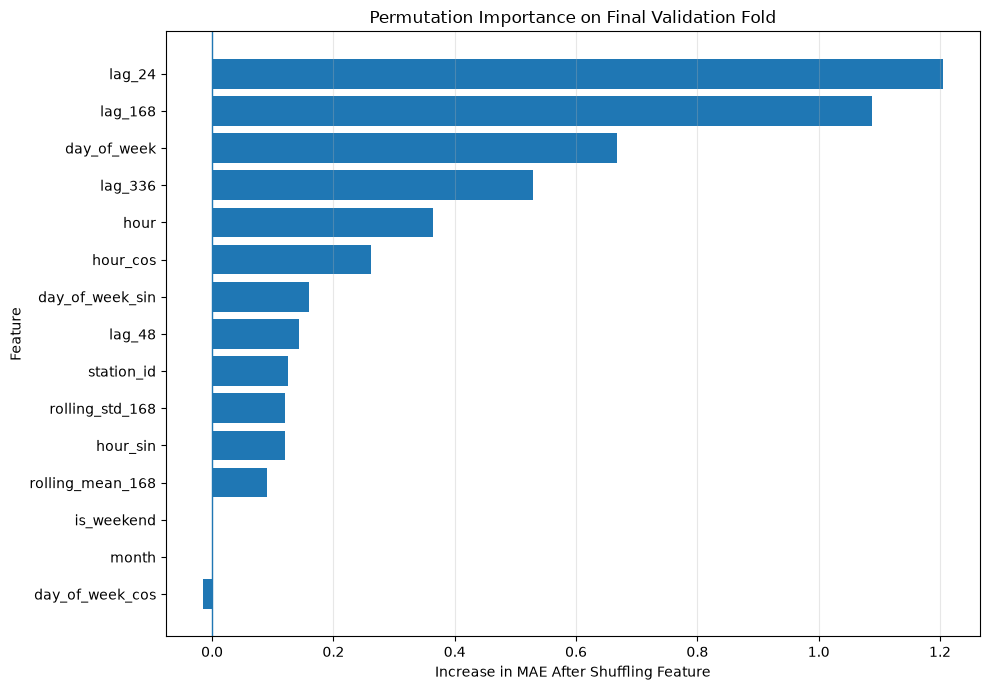

In [15]:
top_importance = importance_results.sort_values(
    "MAE_increase",
    ascending=True,
)

fig, ax = plt.subplots(figsize=(10, 7))

ax.barh(
    top_importance["feature"],
    top_importance["MAE_increase"],
)

ax.axvline(
    0,
    linewidth=1,
)

ax.set_title("Permutation Importance on Final Validation Fold")
ax.set_xlabel("Increase in MAE After Shuffling Feature")
ax.set_ylabel("Feature")
ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()